# 02. Insight Generation

This notebook focuses on Exploratory Data Analysis (EDA) and generating insights from the Rossmann Store Sales data.

In [10]:
# Imports
import pandas as pd
from pandas import Series, DataFrame
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

In [11]:
# Load Interim Data
train_df = pd.read_csv('interim_train.csv')
test_df = pd.read_csv('interim_test.csv')
store_df = pd.read_csv('interim_store.csv')

# Merge store data for analysis
train_store = pd.merge(train_df, store_df, on='Store')

print("Data loaded successfully.")

Data loaded successfully.


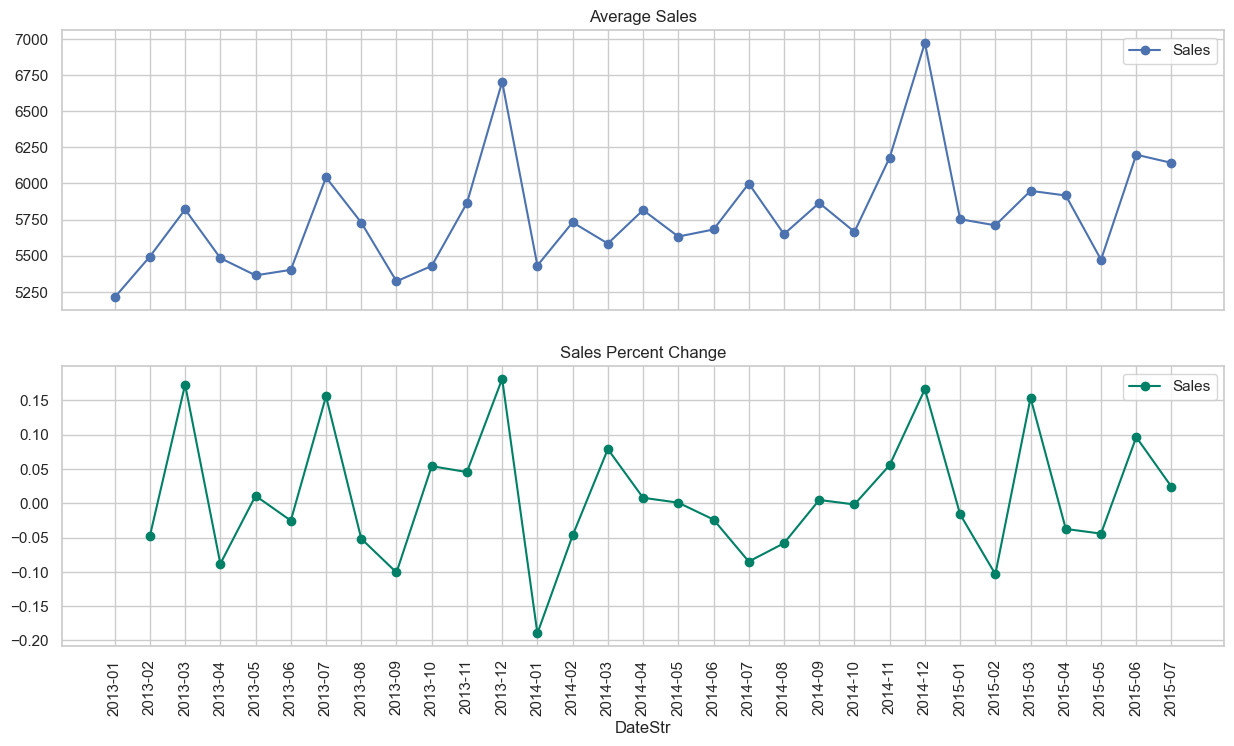

In [12]:
# Sales Trends over Time
# Group by DateStr (Year-Month)
average_sales = train_df.groupby('DateStr')["Sales"].mean()
pct_change_sales = train_df.groupby('DateStr')["Sales"].sum().pct_change()

fig, (axis1, axis2) = plt.subplots(2, 1, sharex=True, figsize=(15, 8))

# Plot average sales
ax1 = average_sales.plot(legend=True, ax=axis1, marker='o', title="Average Sales")
ax1.set_xticks(range(len(average_sales)))
ax1.set_xticklabels(average_sales.index.tolist(), rotation=90)

# Plot percent change
ax2 = pct_change_sales.plot(legend=True, ax=axis2, marker='o', rot=90, colormap="summer", title="Sales Percent Change")
plt.show()

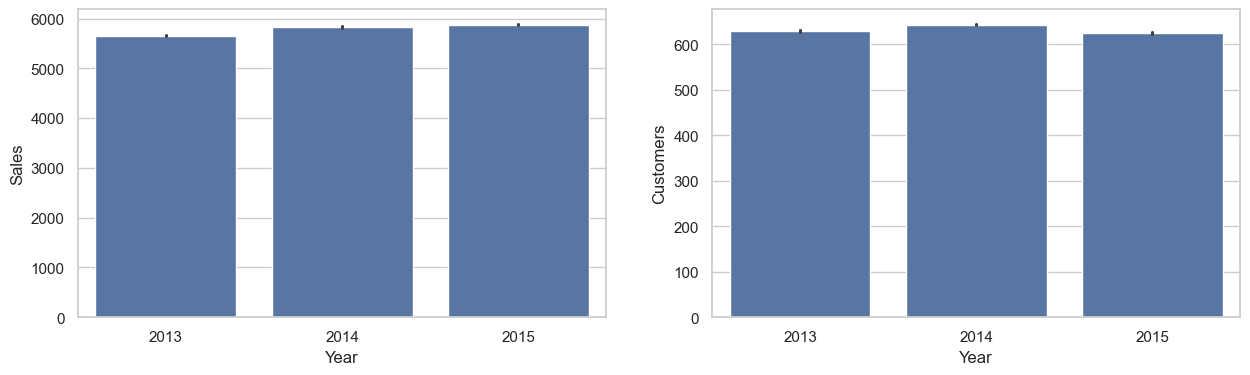

In [13]:
# Sales vs Customers by Year
fig, (axis1, axis2) = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(x='Year', y='Sales', data=train_df, ax=axis1)
sns.barplot(x='Year', y='Customers', data=train_df, ax=axis2)
plt.show()

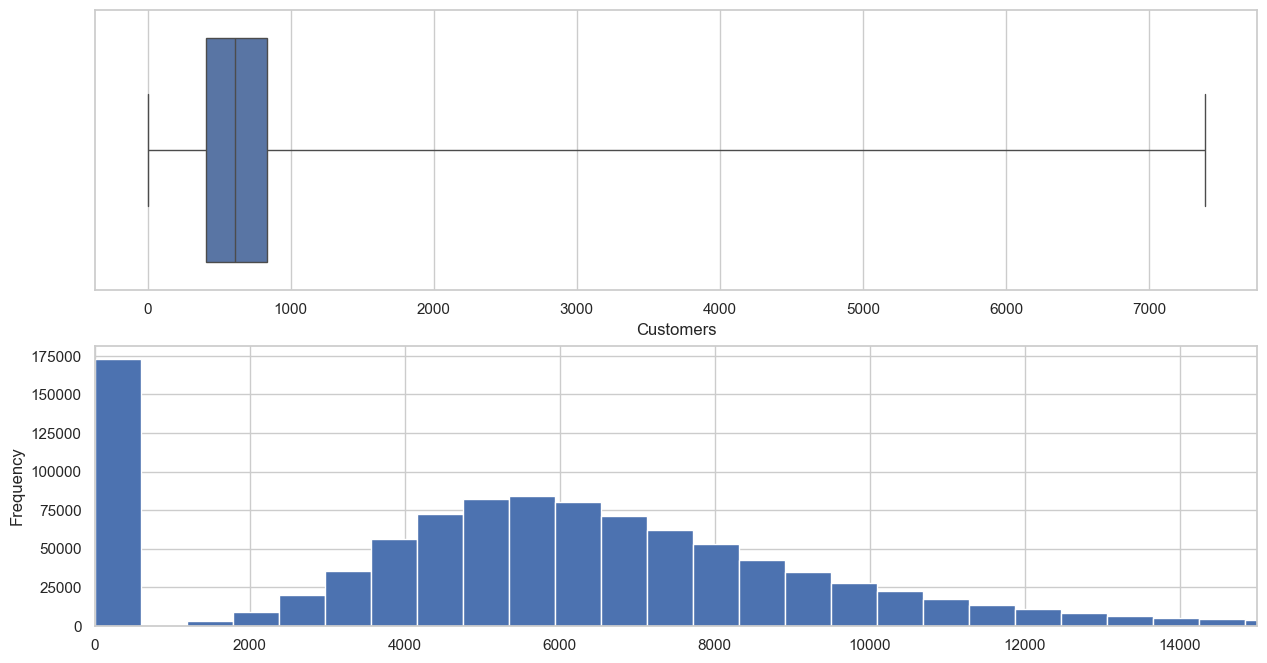

In [14]:
# Sales and Customers Distribution
fig, (axis1, axis2) = plt.subplots(2, 1, figsize=(15, 8))

# Boxplot for Customers
sns.boxplot(x=train_df["Customers"], whis=np.inf, ax=axis1)

# Sales Histogram
train_df["Sales"].plot(kind='hist', bins=70, xlim=(0, 15000), ax=axis2)
plt.show()

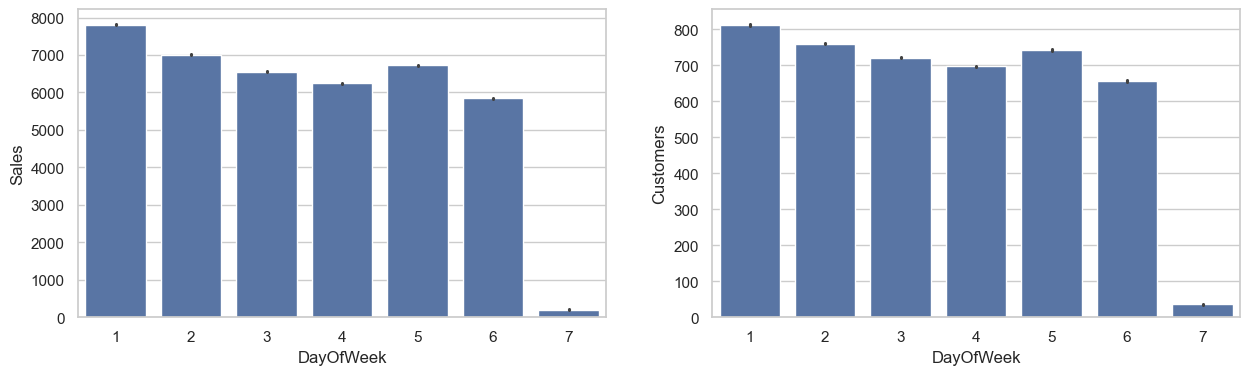

In [15]:
# DayOfWeek Analysis
fig, (axis1, axis2) = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(x='DayOfWeek', y='Sales', data=train_df, order=[1, 2, 3, 4, 5, 6, 7], ax=axis1)
sns.barplot(x='DayOfWeek', y='Customers', data=train_df, order=[1, 2, 3, 4, 5, 6, 7], ax=axis2)
plt.show()

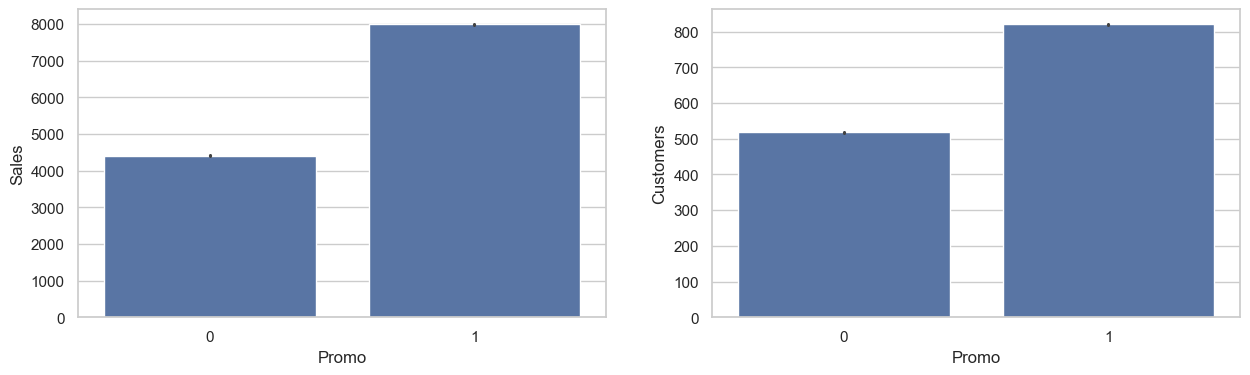

In [16]:
# Promo Impact
fig, (axis1, axis2) = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(x='Promo', y='Sales', data=train_df, ax=axis1)
sns.barplot(x='Promo', y='Customers', data=train_df, ax=axis2)
plt.show()

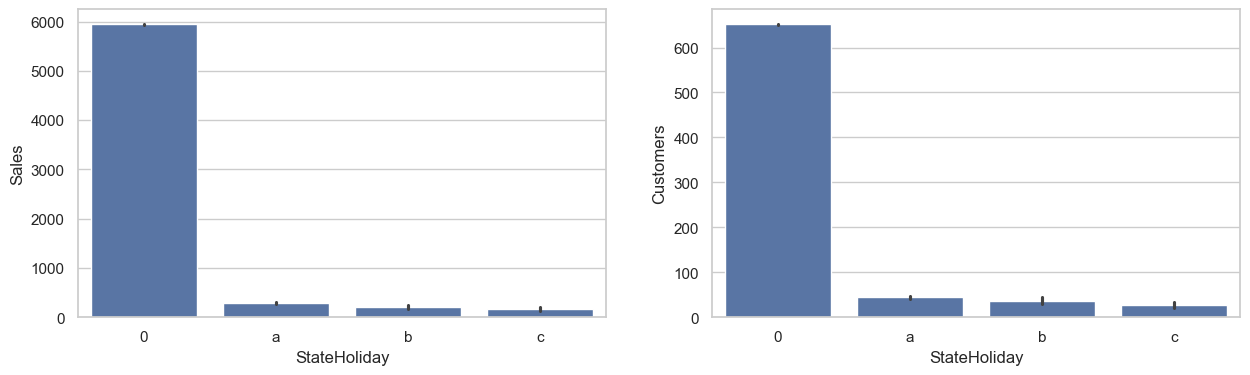

In [17]:
# StateHoliday Impact
fig, (axis1, axis2) = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(x='StateHoliday', y='Sales', data=train_df, ax=axis1)
sns.barplot(x='StateHoliday', y='Customers', data=train_df, ax=axis2)
plt.show()

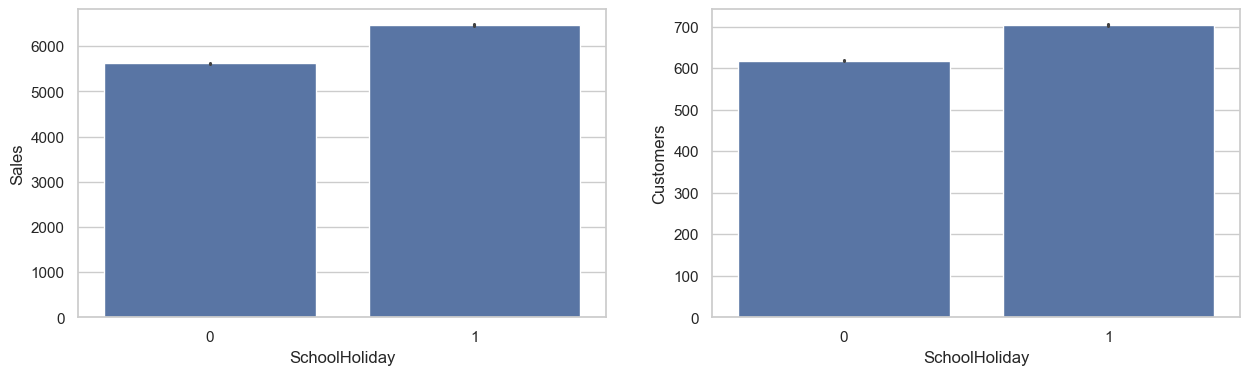

In [18]:
# SchoolHoliday Impact
fig, (axis1, axis2) = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(x='SchoolHoliday', y='Sales', data=train_df, ax=axis1)
sns.barplot(x='SchoolHoliday', y='Customers', data=train_df, ax=axis2)
plt.show()

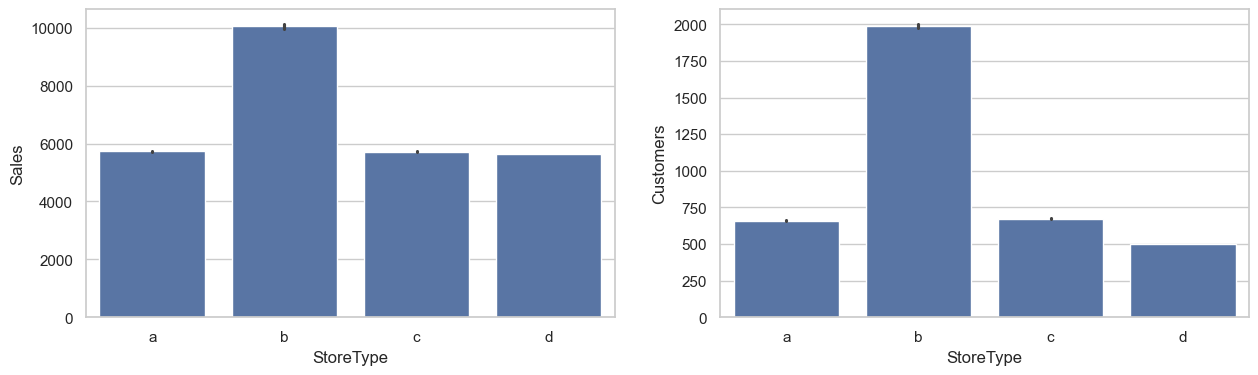

In [19]:
# StoreType Analysis
train_store['StoreType'] = train_store['StoreType'].astype(str)
fig, (axis1, axis2) = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(x='StoreType', y='Sales', data=train_store, order=['a', 'b', 'c', 'd'], ax=axis1)
sns.barplot(x='StoreType', y='Customers', data=train_store, order=['a', 'b', 'c', 'd'], ax=axis2)
plt.show()

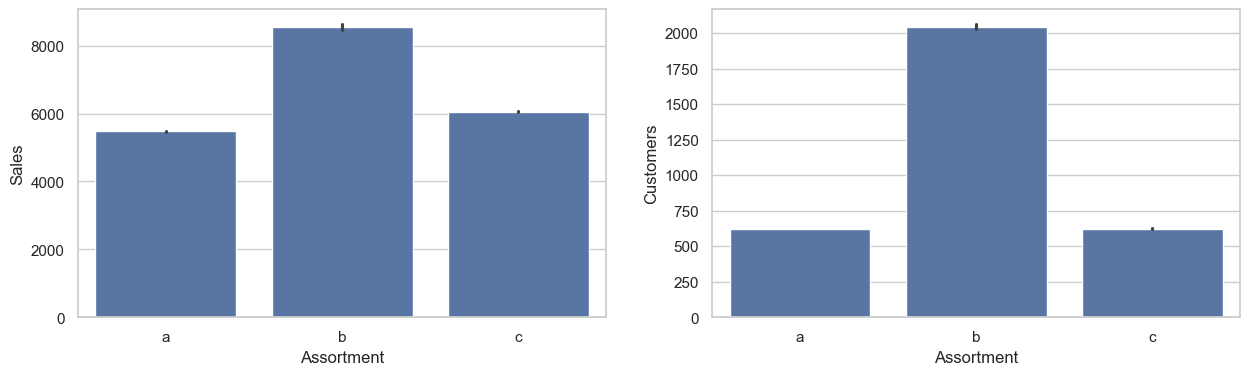

In [20]:
# Assortment Analysis
train_store['Assortment'] = train_store['Assortment'].astype(str)
fig, (axis1, axis2) = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(x='Assortment', y='Sales', data=train_store, order=['a', 'b', 'c'], ax=axis1)
sns.barplot(x='Assortment', y='Customers', data=train_store, order=['a', 'b', 'c'], ax=axis2)
plt.show()

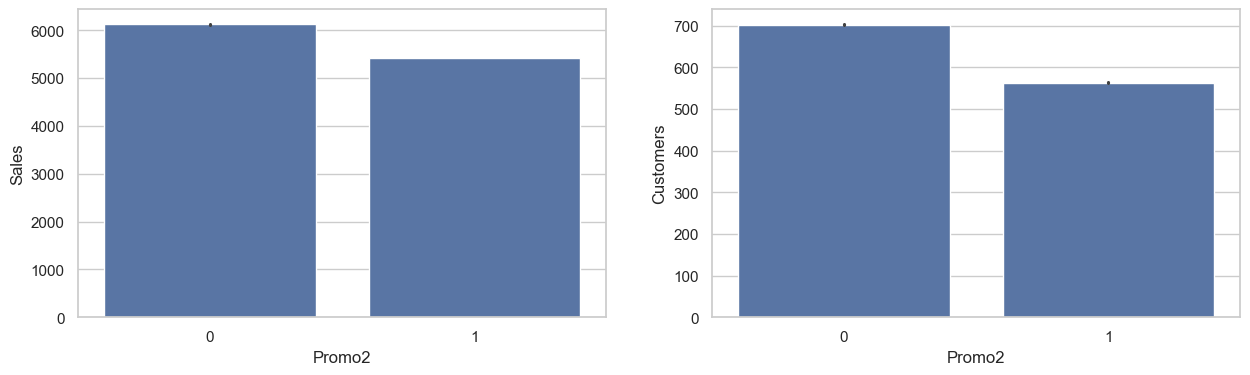

In [21]:
# Promo2 Analysis
fig, (axis1, axis2) = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(x='Promo2', y='Sales', data=train_store, ax=axis1)
sns.barplot(x='Promo2', y='Customers', data=train_store, ax=axis2)
plt.show()

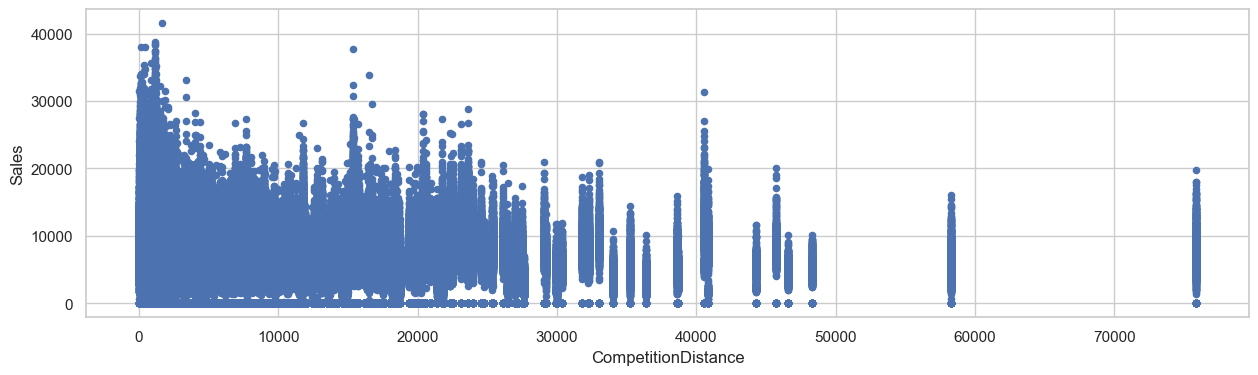

In [22]:
# CompetitionDistance vs Sales
train_store.plot(kind='scatter', x='CompetitionDistance', y='Sales', figsize=(15, 4))
plt.show()

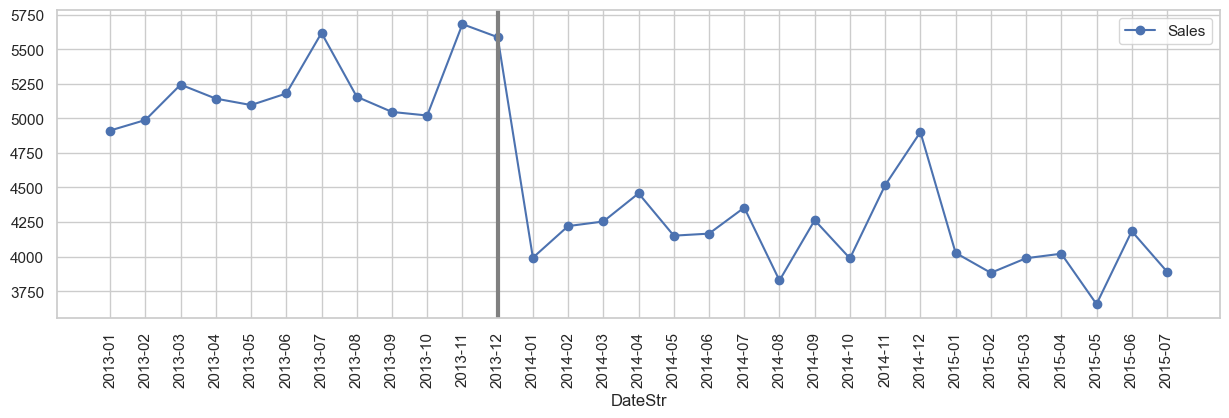

In [23]:
# Store 6 Competition Impact Analysis
store_id = 6
store_data = train_df[train_df["Store"] == store_id]
average_store_sales = store_data.groupby('DateStr')["Sales"].mean()

# Get year and month when Competition started
y = store_df.loc[store_df["Store"] == store_id, "CompetitionOpenSinceYear"].values[0]
m = store_df.loc[store_df["Store"] == store_id, "CompetitionOpenSinceMonth"].values[0]

ax = average_store_sales.plot(legend=True, figsize=(15, 4), marker='o')
ax.set_xticks(range(len(average_store_sales)))
ax.set_xticklabels(average_store_sales.index.tolist(), rotation=90)

if y >= 2013 and not np.isnan(y) and not np.isnan(m):
    plt.axvline(x=((y - 2013) * 12) + (m - 1), linewidth=3, color='grey')
plt.show()

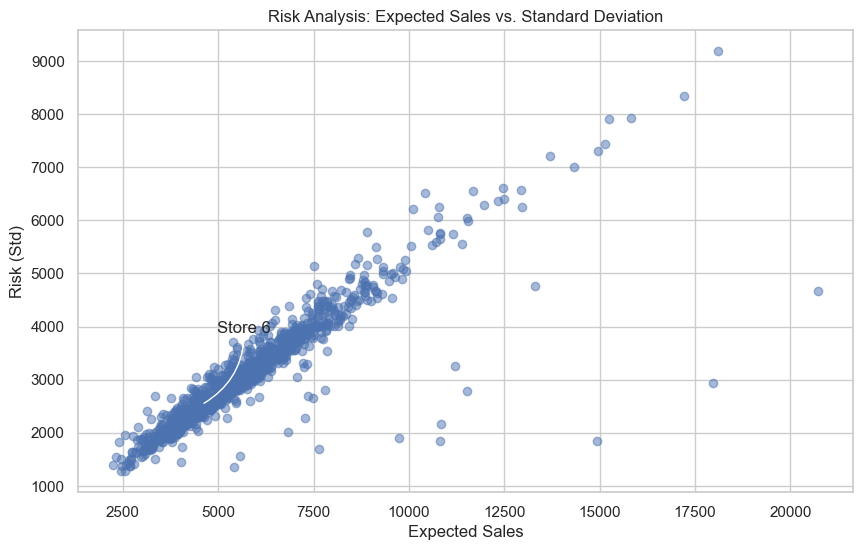

In [24]:
# Risk Analysis (Std vs Mean)
store_means = train_df.groupby('Store')["Sales"].mean()
store_stds = train_df.groupby('Store')["Sales"].std()

plt.figure(figsize=(10, 6))
plt.scatter(store_means, store_stds, alpha=0.5)
plt.xlabel('Expected Sales')
plt.ylabel('Risk (Std)')
plt.title('Risk Analysis: Expected Sales vs. Standard Deviation')

# Annotate Store 6
store_id = 6
plt.annotate(
    f"Store {store_id}",
    xy=(store_means[store_id], store_stds[store_id]),
    xytext=(50, 50),
    textcoords='offset points', ha='right', va='bottom',
    arrowprops=dict(arrowstyle='-', connectionstyle='arc3,rad=-0.3')
)
plt.show()

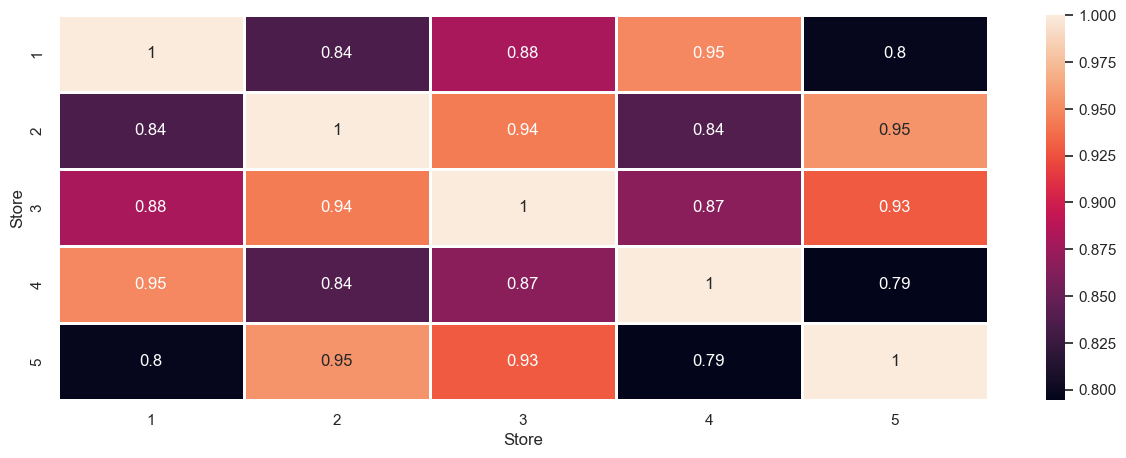

In [25]:
# Correlation Heatmap (First 5 stores)
store_piv = pd.pivot_table(train_df, values='Sales', index='Date', columns=['Store'], aggfunc='sum')
start_store = 1
end_store = 5

plt.figure(figsize=(15, 5))
sns.heatmap(store_piv[list(range(start_store, end_store + 1))].corr(), annot=True, linewidths=2)
plt.show()